# EDB: geometry creation

This example shows how you can use EDB to create a layout.
## Final expected project

<img src="_static/diff_via.png" width="500">

## Perform imports and define constants

Perform required imports.

In [1]:
import os
import tempfile

import pyedb

In [2]:
temp_dir = tempfile.TemporaryDirectory(suffix=".ansys")
aedb_path = os.path.join(temp_dir.name, "create_via.aedb")
print(f"AEDB file path: {aedb_path}")

# Select EDB version (change it manually if needed, e.g. "2025.1")
edb_version = "2025.1"
print(f"EDB version: {edb_version}")

edb = pyedb.Edb(edbpath=aedb_path, edbversion=edb_version)

AEDB file path: C:\Users\ansys\AppData\Local\Temp\tmpertctd15.ansys\create_via.aedb
EDB version: 2025.1


PyEDB INFO: StdOut is enabled


PyEDB INFO: Logger is initialized in EDB.


PyEDB INFO: legacy v0.50.1


PyEDB INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


PyEDB INFO: EDB C:\Users\ansys\AppData\Local\Temp\tmpertctd15.ansys\create_via.aedb created correctly.


PyEDB INFO: EDB initialized.


## Add stackup layers
Add stackup layers.
A stackup can be created layer by layer or imported from a CSV file or XML file.

In [3]:
edb.stackup.add_layer("GND")
edb.stackup.add_layer("Diel", "GND", layer_type="dielectric", thickness="0.1mm", material="FR4_epoxy")
edb.stackup.add_layer("TOP", "Diel", thickness="0.05mm")

## Create signal net and ground planes
Create a signal net and ground planes.

In [4]:
points = [[0.0, 0], [100e-3, 0.0]]
edb.modeler.create_trace(points, "TOP", width=1e-3)
points = [[0.0, 1e-3], [0.0, 10e-3], [100e-3, 10e-3], [100e-3, 1e-3], [0.0, 1e-3]]
edb.modeler.create_polygon(points, "TOP")
points = [[0.0, -1e-3], [0.0, -10e-3], [100e-3, -10e-3], [100e-3, -1e-3], [0.0, -1e-3]]
edb.modeler.create_polygon(points, "TOP")

## Create vias with parametric positions
Create vias with parametric positions.

In [5]:
edb.padstacks.create("MyVia")
edb.padstacks.place([5e-3, 5e-3], "MyVia")
edb.padstacks.place([15e-3, 5e-3], "MyVia")
edb.padstacks.place([35e-3, 5e-3], "MyVia")
edb.padstacks.place([45e-3, 5e-3], "MyVia")
edb.padstacks.place([5e-3, -5e-3], "MyVia")
edb.padstacks.place([15e-3, -5e-3], "MyVia")
edb.padstacks.place([35e-3, -5e-3], "MyVia")
edb.padstacks.place([45e-3, -5e-3], "MyVia")

PyEDB INFO: Padstack MyVia create correctly


## Generate geometry plot

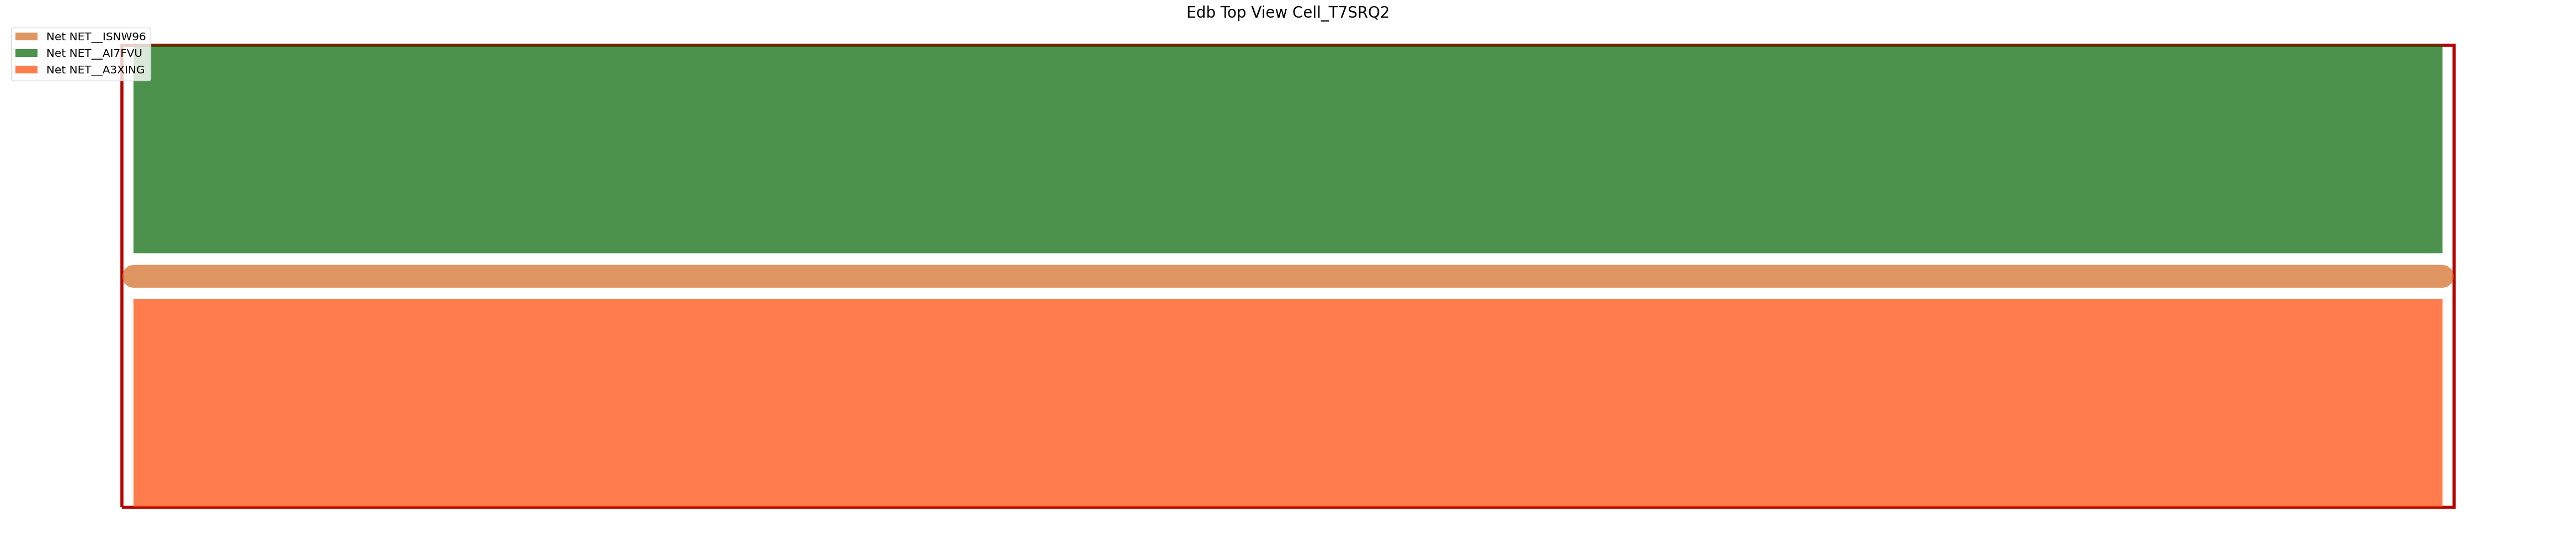

PyEDB INFO: Plot Generation time 0.422


(<Figure size 6000x3000 with 1 Axes>,
 <Axes: title={'center': 'Edb Top View Cell_T7SRQ2'}>)

In [6]:
edb.nets.plot(None, color_by_net=True)

## Generate stackup plot

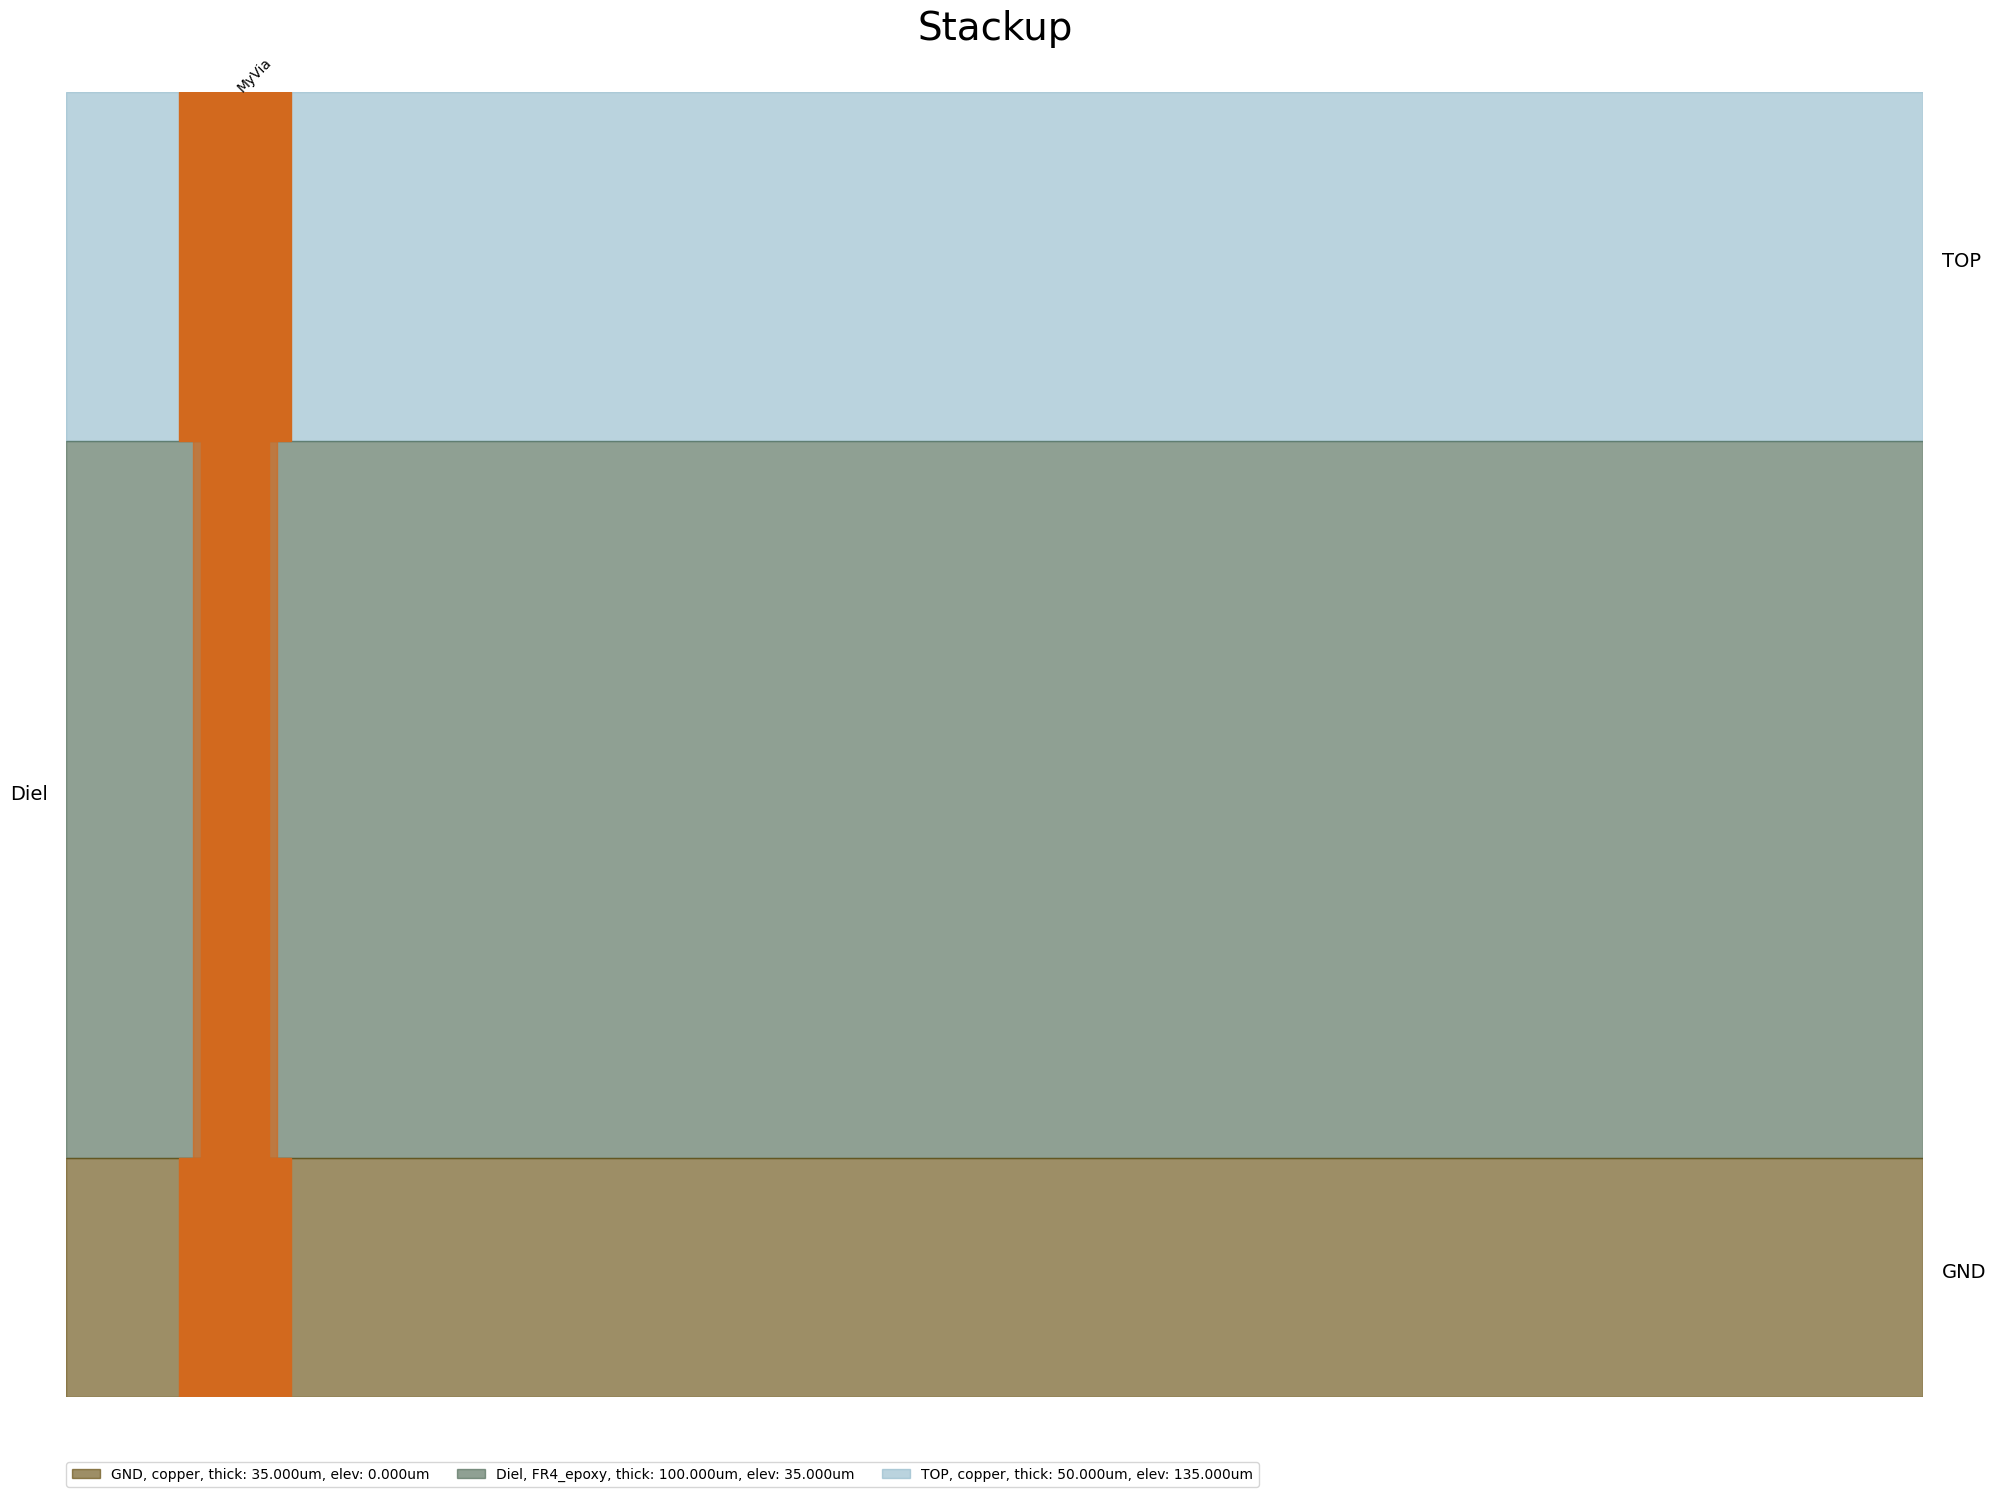

<module 'matplotlib.pyplot' from 'C:\\actions-runner\\_work\\pyaedt-examples\\pyaedt-examples\\.venv\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [7]:
edb.stackup.plot(plot_definitions="MyVia")

## Save and close EDB
Save and close EDB.

In [8]:
if edb:
    edb.save_edb()
    edb.close_edb()
print("EDB saved correctly to {}. You can import in AEDT.".format(aedb_path))

PyEDB INFO: EDB file save time: 0.00ms


PyEDB INFO: EDB file release time: 0.00ms


EDB saved correctly to C:\Users\ansys\AppData\Local\Temp\tmpertctd15.ansys\create_via.aedb. You can import in AEDT.


### Clean up temporary directory

The following command removes the project and the temporary directory.
If you'd like to save this project, save it to a folder of your choice
prior to running the following cell.

In [9]:
temp_dir.cleanup()